# Zomato & It's Restaurant Data Analysis

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
sns.set(style='whitegrid')

In [35]:
df = pd.read_csv('../data/zomato.csv', encoding='latin-1')

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [36]:
df = df[['Restaurant Name','City','Cuisines','Average Cost for two','Aggregate rating','Votes']]
df.dropna(inplace=True)
df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'])
df.head()

,Restaurant Name,City,Cuisines,Average Cost for two,Aggregate rating,Votes
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",1100,4.8,314
1,Izakaya Kikufuji,Makati City,Japanese,1200,4.5,591
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,4.4,270
3,Ooma,Mandaluyong City,"Japanese, Sushi",1500,4.9,365
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",1500,4.8,229


In [37]:
conn = sqlite3.connect('zomato_analysis.db')
df.to_sql('restaurants', conn, if_exists='replace', index=False)

9542

In [38]:
query = '''SELECT City, COUNT(*) as restaurant_count FROM restaurants GROUP BY City ORDER BY restaurant_count DESC LIMIT 10'''
city_counts = pd.read_sql(query, conn)
city_counts

,City,restaurant_count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Lucknow,21
6,Guwahati,21
7,Bhubaneshwar,21
8,Amritsar,21
9,Ahmedabad,21


In [39]:
df['Cuisines'] = df['Cuisines'].str.split(',')
cuisine_df = df.explode('Cuisines')
top_cuisines = cuisine_df['Cuisines'].value_counts().head(10)
top_cuisines

Cuisines
North Indian     2992
 Chinese         1880
 Fast Food       1314
 North Indian     968
Chinese           855
 Mughlai          780
Fast Food         672
Bakery            621
Cafe              617
 Italian          530
Name: count, dtype: int64

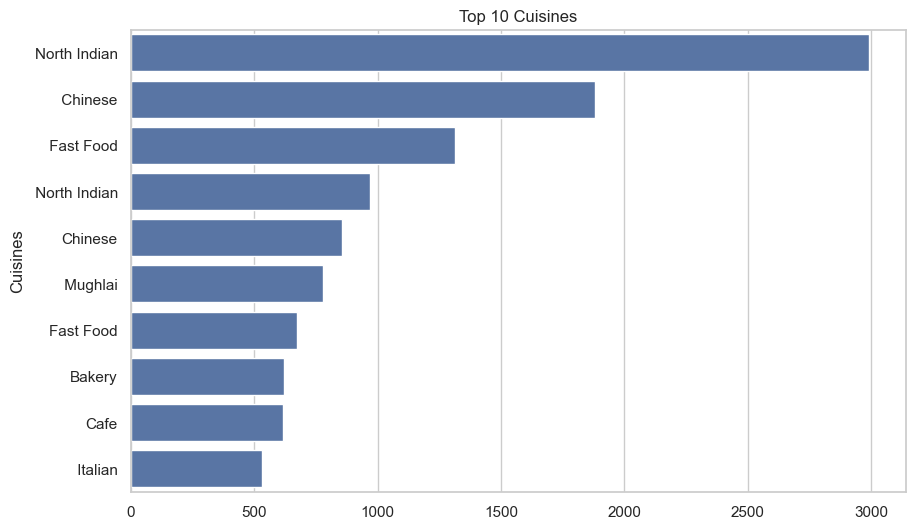

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title('Top 10 Cuisines')
plt.show()

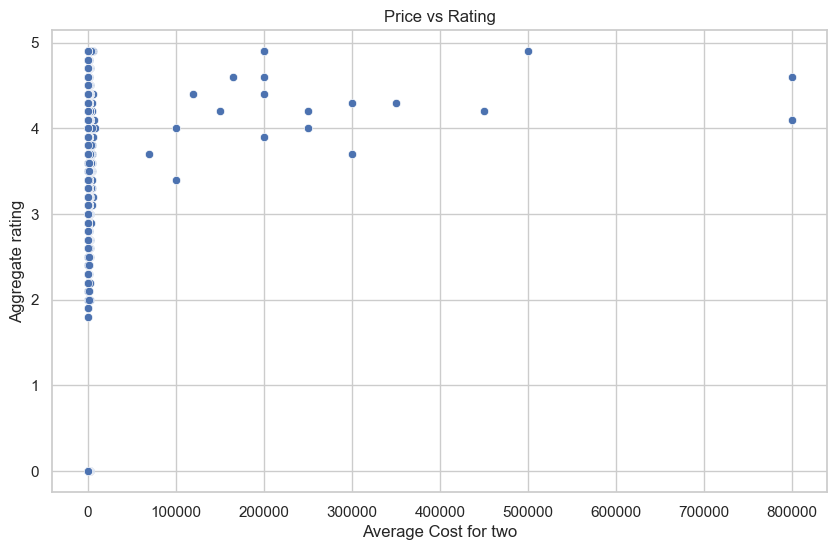

In [41]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Average Cost for two'], y=df['Aggregate rating'])
plt.title('Price vs Rating')
plt.show()

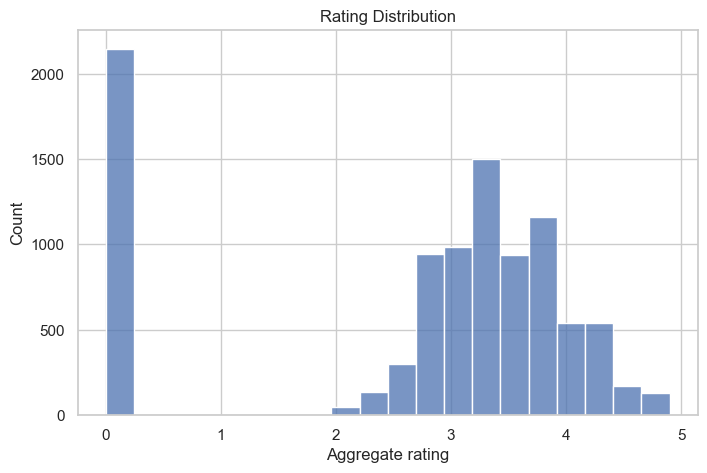

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20)
plt.title('Rating Distribution')
plt.show()